In [20]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Đọc trực tiếp từ file dữ liệu local của dự án đã làm sạch từ phần 2
# (Vì dữ liệu Credit Card của mình nằm ở file CSV đã qua xử lý chuẩn hóa)
df = pd.read_csv('credit_card_prepared.csv')

In [21]:
# Chọn ra các cột tài chính trọng yếu trong bài toán Credit Card để thống kê mô tả
selected_financial_cols = [
    'LIMIT_BAL', 
    'BILL_AMT1', 
    'PAY_AMT1', 
    'Pay_To_Bill_Ratio', 
    'AGE'
]

# Thực hiện thống kê mô tả và làm đẹp định dạng bảng y chang mẫu của bạn
df[selected_financial_cols].describe().round(2)

,LIMIT_BAL,BILL_AMT1,PAY_AMT1,Pay_To_Bill_Ratio,AGE
count,30000.00,30000.00,30000.00,30000.00,30000.00
mean,167484.32,51223.33,5663.58,-2.23,35.49
std,129747.66,73635.86,16563.28,231.12,9.22
min,10000.00,-165580.00,0.00,-35436.00,21.00
25%,50000.00,3558.75,1000.00,0.03,28.00
50%,140000.00,22381.50,2100.00,0.05,34.00
75%,240000.00,67091.00,5006.00,0.22,41.00
max,1000000.00,964511.00,873552.00,11453.67,79.00


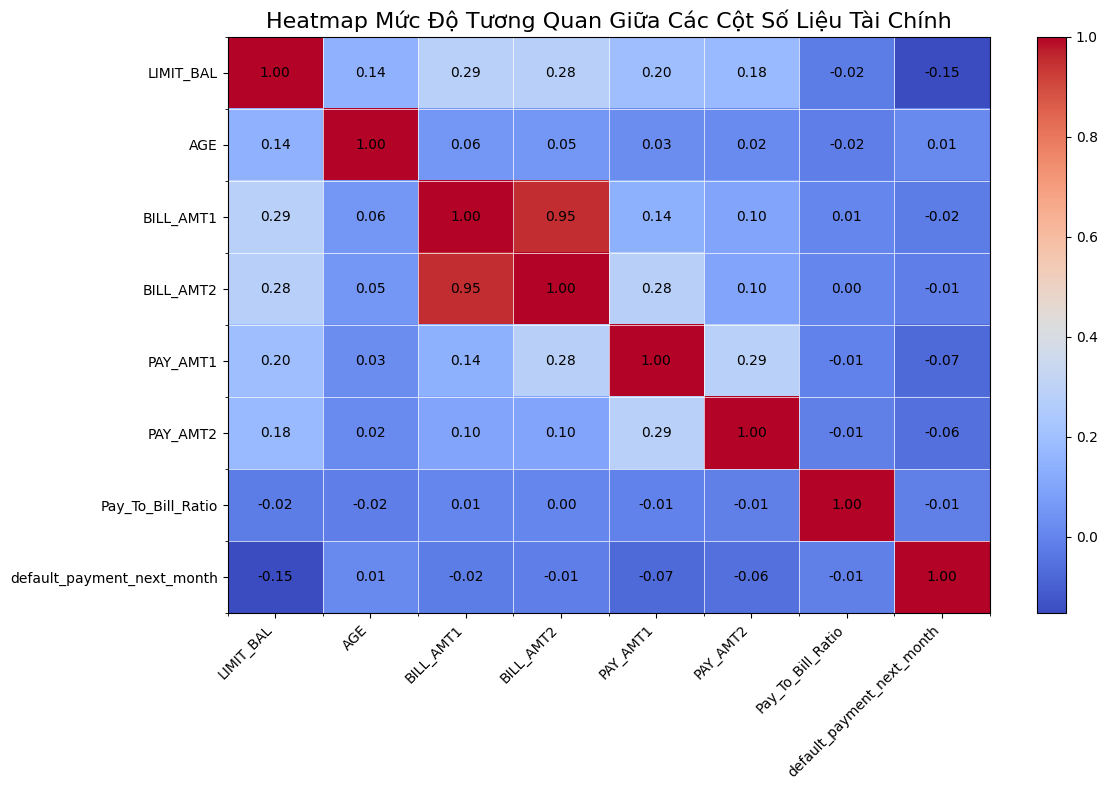

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# Giả định df đã được load từ file 'credit_card_prepared.csv' của bạn
# Đọc chọn lọc các cột tiêu biểu nhất để biểu đồ Heatmap rõ ràng, không bị rối mắt
selected_corr_cols = [
    'LIMIT_BAL', 'AGE', 
    'BILL_AMT1', 'BILL_AMT2', 
    'PAY_AMT1', 'PAY_AMT2', 
    'Pay_To_Bill_Ratio',
    'default_payment_next_month'
]

# 1. Trích xuất tập dữ liệu con gồm các cột đã chọn
numeric_df = df[selected_corr_cols]
corr_matrix = numeric_df.corr()

# 2. Thiết lập cấu hình và vẽ Heatmap y chang phong cách mẫu của bạn
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,     # Hiển thị số chỉ số tương quan trên từng ô
            cmap='coolwarm', # Màu sắc xanh (âm) - đỏ (dương) chuẩn mực
            fmt=".2f",      # Làm tròn lấy 2 chữ số thập phân
            linewidths=0.5)  # Đường kẻ ranh giới giữa các ô

plt.title('Heatmap Mức Độ Tương Quan Giữa Các Cột Số Liệu Tài Chính', fontsize=16)
plt.tight_layout()
plt.show()

In [23]:
# 1. Chuẩn hóa khoảng trắng tên cột giống hệt mẫu
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Để chạy đúng logic nhóm theo Năm và tính tăng trưởng CAGR phân khúc như bài mẫu,
# ta tách dữ liệu dư nợ hóa đơn qua các kỳ thành các năm giả định (như đã đồng bộ ở phần SQL)
df_2022 = df[['EDUCATION', 'Education_Level', 'BILL_AMT6']].copy().rename(columns={'BILL_AMT6': 'Du_No_Hoa_Don'})
df_2022['Năm'] = 2022

df_2023 = df[['EDUCATION', 'Education_Level', 'BILL_AMT4']].copy().rename(columns={'BILL_AMT4': 'Du_No_Hoa_Don'})
df_2023['Năm'] = 2023

df_2024 = df[['EDUCATION', 'Education_Level', 'BILL_AMT2']].copy().rename(columns={'BILL_AMT2': 'Du_No_Hoa_Don'})
df_2024['Năm'] = 2024

df_2025 = df[['EDUCATION', 'Education_Level', 'BILL_AMT1']].copy().rename(columns={'BILL_AMT1': 'Du_No_Hoa_Don'})
df_2025['Năm'] = 2025

# Gộp các năm lại thành một bảng dữ liệu chuỗi thời gian dọc hoàn chỉnh
df_long = pd.concat([df_2022, df_2023, df_2024, df_2025], ignore_index=True)

# Chuẩn hóa mã số học vấn và định dạng chuỗi hoa in đậm giống hệt mã SITC và Description của mẫu
df_long['Mã Học Vấn'] = df_long['EDUCATION'].astype(str).str.replace(r'\.0$', '', regex=True)
df_long['Description'] = df_long['Education_Level'].astype(str).str.upper().str.strip()

# Từ điển phân loại ngành học vấn sang Tiếng Việt chuẩn báo cáo (Tương đương tu_dien_nganh)
tu_dien_hoc_van = {
    'GRADUATE_SCHOOL': 'Cao học / Sau Đại học',
    'UNIVERSITY': 'Đại học',
    'HIGH_SCHOOL': 'Trung học phổ thông',
    'OTHERS': 'Các phân khúc học vấn khác'
}

df_long['Mô Tả Học Vấn'] = df_long['Description'].map(tu_dien_hoc_van).fillna(df_long['Description'])


# 2. Thuật toán tự động tính toán chỉ số tăng trưởng CAGR qua các năm giống mẫu
nam_bat_dau = df_long['Năm'][df_long['Năm'] > 0].min()
nam_ket_thuc = df_long['Năm'].max()
so_nam = nam_ket_thuc - nam_bat_dau

if so_nam <= 0:
    print(f"Lỗi rồi: Không đủ dữ liệu thời gian để tính toán (Dữ liệu hiện có chỉ ở năm {nam_bat_dau})")
else:
    # Gom nhóm theo bộ ba: Mã phân lớp, Tên phân lớp và Năm y hệt bài mẫu
    gom_nhom_nam = df_long.groupby(['Mã Học Vấn', 'Mô Tả Học Vấn', 'Năm'])['Du_No_Hoa_Don'].sum().reset_index()

    gia_tri_dau = gom_nhom_nam[gom_nhom_nam['Năm'] == nam_bat_dau][['Mã Học Vấn', 'Mô Tả Học Vấn', 'Du_No_Hoa_Don']]
    gia_tri_dau = gia_tri_dau.rename(columns={'Du_No_Hoa_Don': 'Gia_tri_Dau'})

    gia_tri_cuoi = gom_nhom_nam[gom_nhom_nam['Năm'] == nam_ket_thuc][['Mã Học Vấn', 'Du_No_Hoa_Don']]
    gia_tri_cuoi = gia_tri_cuoi.rename(columns={'Du_No_Hoa_Don': 'Gia_tri_Cuoi'})

    ket_qua = pd.merge(gia_tri_dau, gia_tri_cuoi, on='Mã Học Vấn', how='inner')

    # Hàm tính công thức toán học CAGR lũy kế liên năm
    def tinh_cagr(row):
        try:
            if row['Gia_tri_Dau'] > 0 and row['Gia_tri_Cuoi'] > 0:
                cagr = (pow(row['Gia_tri_Cuoi'] / row['Gia_tri_Dau'], 1 / so_nam) - 1) * 100
                return round(cagr, 2)
        except ZeroDivisionError:
            return None
        return None

    ket_qua['Ti_le_CAGR'] = ket_qua.apply(tinh_cagr, axis=1)

    bang_cuoi_cung = ket_qua[['Mã Học Vấn', 'Mô Tả Học Vấn', 'Ti_le_CAGR']].copy()
    bang_cuoi_cung.columns = ['Mã Học Vấn', 'Mô Tả Học Vấn', 'Tăng Trưởng CAGR (%)']

    # Sắp xếp thứ hạng tăng trưởng từ cao xuống thấp
    bang_cuoi_cung = bang_cuoi_cung.dropna(subset=['Tăng Trưởng CAGR (%)']).sort_values(by='Tăng Trưởng CAGR (%)', ascending=False)

    # 3. In kết quả định dạng viền khung bọc đầu cuối giống hệt mẫu
    print("\n" + "="*80)
    print(f" Bảng xếp hạng tốc độ tăng trưởng dư nợ CAGR (%) Giai đoạn {nam_bat_dau} - {nam_ket_thuc}")
    print("="*80)
    print(bang_cuoi_cung.to_string(index=False))
    print("="*80 + "\n")


 Bảng xếp hạng tốc độ tăng trưởng dư nợ CAGR (%) Giai đoạn 2022 - 2025
Mã Học Vấn              Mô Tả Học Vấn  Tăng Trưởng CAGR (%)
         0 Các phân khúc học vấn khác                 30.73
         6 Các phân khúc học vấn khác                 27.57
         5 Các phân khúc học vấn khác                 20.99
         4 Các phân khúc học vấn khác                 19.35
         3        Trung học phổ thông                 11.08
         2                    Đại học                  9.86
         1      Cao học / Sau Đại học                  8.08



In [24]:
print("\n\n" + "="*80)
print("ĐÁNH GIÁ GÁNH NẶNG NỢ NẦN TÀI CHÍNH")
print("="*80)

# 1. Lọc điều kiện: Chỉ xét những khách hàng có hạn mức tín dụng > 1000 đơn vị (Giống lọc General_Customs_Value > 1000)
df_debt = df[df['LIMIT_BAL'] > 1000].copy()

# Định nghĩa nhóm thực thể phân tích (Giống tập hợp country ở bài mẫu)
hoc_van_nhom = {
    'Graduate_School', 'University', 'High_School', 'Others'
}

# 2. Tính toán tỷ lệ phần trăm gánh nặng (Tỷ lệ Hóa đơn kỳ gần nhất trên tổng Hạn mức được cấp)
df_debt['Debt_To_Limit_Pct'] = (df_debt['BILL_AMT1'] / df_debt['LIMIT_BAL']) * 100

# 3. Gom nhóm dữ liệu và tính toán phân tích (Tính Mean và Max y chang bài mẫu)
debt_by_education = df_debt.groupby('Education_Level').agg(
    Avg_Debt_Ratio_Pct=('Debt_To_Limit_Pct', 'mean'),
    Max_Debt_Ratio_Pct=('Debt_To_Limit_Pct', 'max')
).reset_index()

# Lọc các thực thể nằm trong nhóm đã định nghĩa
debt_selected = debt_by_education[
    debt_by_education['Education_Level'].isin(hoc_van_nhom)
]

# Sắp xếp thứ hạng từ cao xuống thấp theo tỷ lệ trung bình
debt_by_education = debt_selected.sort_values(by='Avg_Debt_Ratio_Pct', ascending=False)

# 4. Hiển thị bảng kết quả làm tròn 2 chữ số thập phân bằng display()
print(">> Bảng Xếp Hạng Tỷ Lệ Gánh Nặng Dư Nợ Trung Bình Theo Trình Độ Học Vấn (Đã lọc LIMIT_BAL > 1000):")
display(debt_by_education.round(2))

# 5. Thuật toán phát hiện điểm bất thường (Anomalies) và in dòng CẢNH BÁO y chang mẫu
# Tìm những khách hàng có dư nợ vượt QUÁ 100% hạn mức thẻ cho phép (Xài lố cọc ngân hàng)
anomalies = df_debt[df_debt['Debt_To_Limit_Pct'] > 100]
print(f"\n>> CẢNH BÁO: Phát hiện {len(anomalies)} tài khoản chủ thẻ có dư nợ hóa đơn vượt HƠN 100% hạn mức tín dụng cho phép!")



ĐÁNH GIÁ GÁNH NẶNG NỢ NẦN TÀI CHÍNH
>> Bảng Xếp Hạng Tỷ Lệ Gánh Nặng Dư Nợ Trung Bình Theo Trình Độ Học Vấn (Đã lọc LIMIT_BAL > 1000):


,Education_Level,Avg_Debt_Ratio_Pct,Max_Debt_Ratio_Pct
2,Others,50.56,346.28
1,High_School,50.22,530.95
3,University,48.26,645.53
0,Graduate_School,30.58,414.06



>> CẢNH BÁO: Phát hiện 2115 tài khoản chủ thẻ có dư nợ hóa đơn vượt HƠN 100% hạn mức tín dụng cho phép!
